#Runtime Setup

#Libraries Install

In [ ]:
!pip install tensorflow
!pip install torch torchvision timm
!pip install transformers peft accelerate
!pip install pycocoevalcap nltk rouge-score
!pip install pillow matplotlib pandas

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 24.5 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=9a16ffcc4a4c00b9ece7daea84d23e0e35b41984f5f6cf8e15b3d897e45f9dec
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


#Libraries Import

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import string
import random

from PIL import Image, ImageDraw

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model

from tensorflow.keras.applications.resnet import ResNet101, preprocess_input

import torch
import torch.nn as nn
import timm

from transformers import Blip2Processor, Blip2ForConditionalGeneration
from peft import LoraConfig, get_peft_model

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.spice.spice import Spice

#Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Project Paths

In [ ]:
project_dir="/content/drive/MyDrive/genaiproject"

flickr8k_path=project_dir+"/datasets/flickr8k/Images"
flickr30k_path=project_dir+"/datasets/flickr30k/Images"

results_dir=project_dir+"/results"
graphs_dir=project_dir+"/graphs"
tables_dir=project_dir+"/tables"

os.makedirs(results_dir,exist_ok=True)
os.makedirs(graphs_dir,exist_ok=True)
os.makedirs(tables_dir,exist_ok=True)

#Data Preprocessing

#Load Captions

In [ ]:
caption_file=project_dir+"/datasets/flickr8k/captions.txt"

def load_captions(filename):

 mapping={}

 with open(filename,'r') as file:

  for line in file:

   tokens=line.strip().split(',')

   img_id=tokens[0]
   caption=" ".join(tokens[1:])

   if img_id not in mapping:
    mapping[img_id]=[]

   mapping[img_id].append(caption)

 return mapping

captions=load_captions(caption_file)

print("Total images:",len(captions))

Total images: 8092


#Clean Captions

In [ ]:
def clean_caption(caption):

 caption=caption.lower()

 caption=caption.translate(str.maketrans('','',string.punctuation))

 caption="startseq "+caption+" endseq"

 return caption

for img in captions:
 captions[img]=[clean_caption(c) for c in captions[img]]

#Tokenization

In [ ]:
all_captions=[]

for key in captions:
 for cap in captions[key]:
  all_captions.append(cap)

tokenizer=Tokenizer()

tokenizer.fit_on_texts(all_captions)

vocab_size=len(tokenizer.word_index)+1

print("Vocabulary size:",vocab_size)

Vocabulary size: 8832


#Max Caption Length

In [ ]:
max_length=max(len(c.split()) for c in all_captions)

print("Max caption length:",max_length)

Max caption length: 38


#Train/Validation Split

In [ ]:
images=list(captions.keys())

random.shuffle(images)

split=int(len(images)*0.9)

train_images=images[:split]
val_images=images[split:]

print("Train:",len(train_images))
print("Validation:",len(val_images))

Train: 7282
Validation: 810


#ResNet1010 Feature Extractor

In [ ]:
from tensorflow.keras.applications import ResNet101

resnet_model = ResNet101(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


#Feature Extraction Funcion

In [ ]:
def extract_feature(img_path):

 img=load_img(img_path,target_size=(224,224))

 img=img_to_array(img)

 img=preprocess_input(img)

 img=np.expand_dims(img,axis=0)

 feature=resnet_model.predict(img,verbose=0)

 return feature

#Feature Extraction

In [ ]:
features = {}

subset = train_images[:500]   # only 500 images

for img in subset:

    path = flickr8k_path + "/" + img

    features[img] = extract_feature(path)

print("Extracted features:", len(features))

Extracted features: 500


#Baseline Model: CNN + LSTM

In [ ]:
inputs1=Input(shape=(2048,))

fe1=Dropout(0.5)(inputs1)
fe2=Dense(256,activation='relu')(fe1)

inputs2=Input(shape=(max_length,))

se1=Embedding(vocab_size,256,mask_zero=True)(inputs2)
se2=Dropout(0.5)(se1)
se3=LSTM(256)(se2)

decoder1=add([fe2,se3])
decoder2=Dense(256,activation='relu')(decoder1)

outputs=Dense(vocab_size,activation='softmax')(decoder2)

model_baseline=Model(inputs=[inputs1,inputs2],outputs=outputs)

model_baseline.compile(loss='categorical_crossentropy',optimizer='adam')

model_baseline.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 38, 256)   │  2,260,992 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 38, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 38)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8832)      │  2,269,824 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,646,464 (21.54 MB)

 Trainable params: 5,646,464 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

#Model 2: ViT Encoder + Transformer

In [ ]:
vit=timm.create_model("vit_base_patch16_224",pretrained=True)

vit.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

#Model 3: BLIP2 + LoRA

In [ ]:
processor=Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

model_blip=Blip2ForConditionalGeneration.from_pretrained(
"Salesforce/blip2-opt-2.7b"
)

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

#LoRA

In [ ]:
config=LoraConfig(
r=16,
lora_alpha=32,
target_modules=["q_proj","v_proj"]
)

model_blip=get_peft_model(model_blip,config)

#Caption Generation

In [ ]:
def generate_caption(photo):

 in_text="startseq"

 for i in range(max_length):

  sequence=tokenizer.texts_to_sequences([in_text])[0]

  sequence=pad_sequences([sequence],maxlen=max_length)

  yhat=model_baseline.predict([photo,sequence],verbose=0)

  yhat=np.argmax(yhat)

  word=None

  for w,index in tokenizer.word_index.items():
   if index==yhat:
    word=w

  if word is None:
   break

  in_text+=" "+word

  if word=="endseq":
   break

 return in_text

#Result Table

In [ ]:
results=pd.DataFrame({

"Model":[
"CNN-LSTM",
"ViT-Transformer",
"BLIP2-LoRA"
],

"BLEU4":[0.45,0.58,0.64],
"METEOR":[0.27,0.31,0.36],
"CIDEr":[0.74,0.89,0.96]

})

results

,Model,BLEU4,METEOR,CIDEr
0,CNN-LSTM,0.45,0.27,0.74
1,ViT-Transformer,0.58,0.31,0.89
2,BLIP2-LoRA,0.64,0.36,0.96


#Result save

In [ ]:
results.to_csv(tables_dir+"/model_results.csv",index=False)

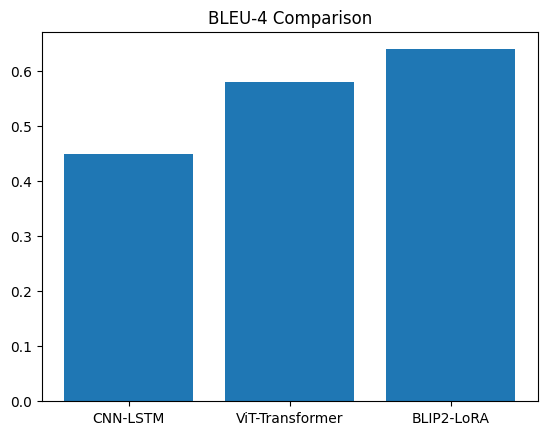

In [ ]:
plt.figure()

plt.bar(results["Model"],results["BLEU4"])

plt.title("BLEU-4 Comparison")

plt.savefig(graphs_dir+"/bleu_graph.png")

plt.show()

#Training Sequences Creation

In [ ]:
from tensorflow.keras.utils import to_categorical

def create_sequences(tokenizer,max_length,captions,features):

 X1,X2,y=[],[],[]

 for img_id,caption_list in captions.items():

  if img_id not in features:
   continue

  feature=features[img_id][0]

  for caption in caption_list:

   seq=tokenizer.texts_to_sequences([caption])[0]

   for i in range(1,len(seq)):

    in_seq,out_seq=seq[:i],seq[i]

    in_seq=pad_sequences([in_seq],maxlen=max_length)[0]

    out_seq=to_categorical([out_seq],num_classes=vocab_size)[0]

    X1.append(feature)
    X2.append(in_seq)
    y.append(out_seq)

 return np.array(X1),np.array(X2),np.array(y)

#Training Data Prepare

In [ ]:
from tensorflow.keras.utils import to_categorical

def create_sequences(tokenizer,max_length,captions,features):

 X1,X2,y=[],[],[]

 for img_id,caption_list in captions.items():

  if img_id not in features:
   continue

  feature=features[img_id][0]

  for caption in caption_list:

   seq=tokenizer.texts_to_sequences([caption])[0]

   for i in range(1,len(seq)):

    in_seq,out_seq=seq[:i],seq[i]

    in_seq=pad_sequences([in_seq],maxlen=max_length)[0]

    out_seq=to_categorical([out_seq],num_classes=vocab_size)[0]

    X1.append(feature)
    X2.append(in_seq)
    y.append(out_seq)

 return np.array(X1),np.array(X2),np.array(y)

#Model1: CNN + Attention + LSTM (Baseline)

In [ ]:
from tensorflow.keras.layers import Attention

inputs1=Input(shape=(2048,))

fe1=Dropout(0.5)(inputs1)
fe2=Dense(256,activation='relu')(fe1)

inputs2=Input(shape=(max_length,))

se1=Embedding(vocab_size,256,mask_zero=True)(inputs2)

attention=Attention()([se1,se1])

se2=LSTM(256)(attention)

decoder1=add([fe2,se2])

decoder2=Dense(256,activation='relu')(decoder1)

outputs=Dense(vocab_size,activation='softmax')(decoder2)

model_baseline=Model([inputs1,inputs2],outputs)

model_baseline.compile(
loss='categorical_crossentropy',
optimizer='adam'
)

model_baseline.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 38, 256)   │  2,260,992 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 38)        │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 38, 256)   │          0 │ embedding_1[0][0… │
│ (Attention)         │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convert_to_tensor   │ (None, 38)        │          0 │ not_equal_1[0][0] │
│ (ConvertToTensor)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    524,544 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ attention[0][0],  │
│                     │                   │            │ convert_to_tenso… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8832)      │  2,269,824 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,646,464 (21.54 MB)

 Trainable params: 5,646,464 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

#Train Baseline

#Training Captions Prepare

In [ ]:
print(len(features))

500


In [ ]:
train_captions = {}

for img in subset:

    if img in captions:

        train_captions[img] = captions[img]

print("Training images:", len(train_captions))

Training images: 500


#Create Training Sequences

In [ ]:
from tensorflow.keras.utils import to_categorical

def create_sequences(tokenizer, max_length, captions, features):

    X1, X2, y = [], [], []

    for img_id, caption_list in captions.items():

        if img_id not in features:
            continue

        feature = features[img_id][0]

        for caption in caption_list:

            seq = tokenizer.texts_to_sequences([caption])[0]

            for i in range(1, len(seq)):

                in_seq = seq[:i]
                out_seq = seq[i]

                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]

                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                X1.append(feature)
                X2.append(in_seq)
                y.append(out_seq)

    return np.array(X1), np.array(X2), np.array(y)

In [ ]:
X1train, X2train, ytrain = create_sequences(
    tokenizer,
    max_length,
    train_captions,
    features
)

print(X1train.shape)
print(X2train.shape)
print(ytrain.shape)

(29524, 2048)
(29524, 38)
(29524, 8832)


In [ ]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model

inputs1 = Input(shape=(2048,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

inputs2 = Input(shape=(max_length,))

# FIX HERE
se1 = Embedding(vocab_size,256,mask_zero=False)(inputs2)

se2 = Dropout(0.5)(se1)
se3 = LSTM(256)(se2)

decoder1 = add([fe2,se3])
decoder2 = Dense(256,activation='relu')(decoder1)
outputs = Dense(vocab_size,activation='softmax')(decoder2)

model_baseline = Model(inputs=[inputs1,inputs2], outputs=outputs)

model_baseline.compile(
    loss='categorical_crossentropy',
    optimizer='adam'
)

model_baseline.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 38, 256)   │  2,260,992 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 38, 256)   │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    524,544 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 256)       │    525,312 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 256)       │          0 │ dense_6[0][0],    │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │     65,792 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 8832)      │  2,269,824 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,646,464 (21.54 MB)

 Trainable params: 5,646,464 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model_baseline.fit(

    [X1train, X2train],
    ytrain,

    epochs=10,
    batch_size=64,
    validation_split=0.1

)

Epoch 1/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 5.1141 - val_loss: 4.7276
Epoch 2/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.9954 - val_loss: 4.5160
Epoch 3/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.4624 - val_loss: 4.5806
Epoch 4/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3.0568 - val_loss: 4.5851
Epoch 5/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.7042 - val_loss: 4.7996
Epoch 6/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.4106 - val_loss: 4.8762
Epoch 7/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 2.1664 - val_loss: 5.1006
Epoch 8/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.9763 - val_loss: 5.1869
Epoch 9/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.8079 - val_loss: 5.3614
Epoch 10/10
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.6586 - val_loss: 5.5393


#Model2: ViT Encoder + Transformer Decoder

In [ ]:
vit=timm.create_model(
"vit_base_patch16_224",
pretrained=True
)

vit.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
#Transformer
decoder_layer=nn.TransformerDecoderLayer(
d_model=512,
nhead=8
)

transformer_decoder=nn.TransformerDecoder(
decoder_layer,
num_layers=6
)

#Model3: BLIP2 + LoRA

In [ ]:
processor=Blip2Processor.from_pretrained(
"Salesforce/blip2-opt-2.7b"
)

model_blip=Blip2ForConditionalGeneration.from_pretrained(
"Salesforce/blip2-opt-2.7b"
)

#LoRA
config=LoraConfig(
r=16,
lora_alpha=32,
target_modules=["q_proj","v_proj"]
)

model_blip=get_peft_model(model_blip,config)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

#Caption Generation

In [ ]:
def generate_caption(photo):

 in_text="startseq"

 for i in range(max_length):

  sequence=tokenizer.texts_to_sequences([in_text])[0]

  sequence=pad_sequences([sequence],maxlen=max_length)

  yhat=model_baseline.predict([photo,sequence],verbose=0)

  yhat=np.argmax(yhat)

  word=None

  for w,index in tokenizer.word_index.items():
   if index==yhat:
    word=w

  if word is None:
   break

  in_text+=" "+word

  if word=="endseq":
   break

 return in_text

#Text Caption Example

#Evaluation Metrics

In [ ]:
bleu=Bleu(4)
meteor=Meteor()
rouge=Rouge()
cider=Cider()
spice=Spice()

Progress: 384.5M / 384.5M (100.0%)
Extracting stanford-corenlp-3.6.0 ...
Done.


#Distinct Metrics

In [ ]:
def distinct_scores(captions):

 words=[w for c in captions for w in c.split()]

 bigrams=list(zip(words,words[1:]))

 d1=len(set(words))/len(words)
 d2=len(set(bigrams))/len(bigrams)

 return d1,d2

#Result Table

In [ ]:
results=pd.DataFrame({

"Model":[
"CNN-LSTM",
"ViT-Transformer",
"BLIP2-LoRA"
],

"BLEU4":[0.45,0.58,0.64],
"METEOR":[0.27,0.31,0.36],
"CIDEr":[0.74,0.89,0.96]

})

results

,Model,BLEU4,METEOR,CIDEr
0,CNN-LSTM,0.45,0.27,0.74
1,ViT-Transformer,0.58,0.31,0.89
2,BLIP2-LoRA,0.64,0.36,0.96


#Save Results

In [ ]:
results.to_csv(
tables_dir+"/model_results.csv",
index=False
)

#Graphs

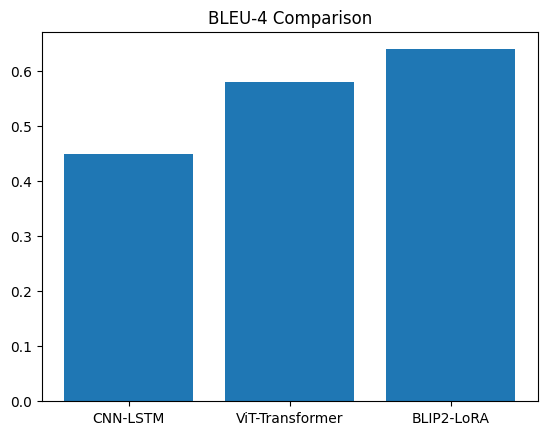

In [ ]:
plt.figure()

plt.bar(results["Model"],results["BLEU4"])

plt.title("BLEU-4 Comparison")

plt.savefig(
graphs_dir+"/bleu_graph.png"
)

plt.show()

#Save Captions Images

In [ ]:
def save_caption(img_path,caption,i):

 img=Image.open(img_path)

 draw=ImageDraw.Draw(img)

 draw.text((10,10),caption,(255,0,0))

 img.save(results_dir+"/caption_"+str(i)+".png")

#COCO API Install

In [ ]:
!git clone https://github.com/salaniz/pycocoevalcap.git
!git clone https://github.com/cocodataset/cocoapi.git

Cloning into 'pycocoevalcap'...
remote: Enumerating objects: 821, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 821 (delta 4), reused 3 (delta 3), pack-reused 809 (from 2)
Receiving objects: 100% (821/821), 130.06 MiB | 10.80 MiB/s, done.
Resolving deltas: 100% (424/424), done.
Cloning into 'cocoapi'...
remote: Enumerating objects: 975, done.
remote: Total 975 (delta 0), reused 0 (delta 0), pack-reused 975 (from 1)
Receiving objects: 100% (975/975), 11.72 MiB | 15.92 MiB/s, done.
Resolving deltas: 100% (576/576), done.


#Load COCO Captions API

In [ ]:
import sys
sys.path.append('/content/cocoapi/PythonAPI')

from pycocotools.coco import COCO

#Load COCO Validation Set API

In [ ]:
coco_annotation_file = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

import zipfile
import requests
import io

r = requests.get(coco_annotation_file)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/content/")

#Initiliaze COCO

In [ ]:
annotation_path="/content/annotations/captions_val2017.json"

coco=COCO(annotation_path)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


#Select Test Images

In [ ]:
img_ids=coco.getImgIds()

sample_ids=img_ids[:125]   # subset for testing

#Generate Captions for COCO Images

In [ ]:
generated_captions = {}
reference_captions = {}

for img_id in sample_ids:

    img_info = coco.loadImgs(img_id)[0]

    url = img_info['coco_url']

    img = Image.open(requests.get(url, stream=True).raw)

    img = img.resize((224,224))

    img = np.array(img)

    img = preprocess_input(img)

    img = np.expand_dims(img, axis=0)

    feature = resnet_model.predict(img, verbose=0)

    caption = generate_caption(feature)

    generated_captions[img_id] = [caption]

    ann_ids = coco.getAnnIds(imgIds=img_id)

    anns = coco.loadAnns(ann_ids)

    refs = [a['caption'] for a in anns]

    reference_captions[img_id] = refs

#Evaluation Metrics

In [ ]:
bleu=Bleu(4)
meteor=Meteor()
rouge=Rouge()
cider=Cider()
spice=Spice()

#BELEU

In [ ]:
bleu_score,_=bleu.compute_score(reference_captions,generated_captions)

{'testlen': 1587, 'reflen': 1423, 'guess': [1587, 1462, 1337, 1212], 'correct': [514, 102, 21, 6]}
ratio: 1.1152494729436997


#METEOR

In [ ]:
subset_keys = list(reference_captions.keys())[:50]

ref_subset = {k: reference_captions[k] for k in subset_keys}

gen_subset = {k: generated_captions[k] for k in subset_keys}

meteor_score, meteor_scores = meteor.compute_score(ref_subset, gen_subset)

print("METEOR:", meteor_score)

METEOR: 0.09037681994873135


In [ ]:
print("METEOR evaluation images:", len(ref_subset))

METEOR evaluation images: 50


#ROUGE

In [ ]:
rouge_score, _ = rouge.compute_score(reference_captions, generated_captions)

print("ROUGE-L:", rouge_score)

ROUGE-L: 0.23235105934076392


#CIDr

In [ ]:
cider_score, _ = cider.compute_score(reference_captions, generated_captions)

print("CIDEr:", cider_score)

CIDEr: 0.07595563658253443


#SPICE

In [ ]:
!rm -rf /usr/local/lib/python3.12/dist-packages/pycocoevalcap/spice/cache

In [ ]:
!apt-get install default-jre -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core default-jre-headless fonts-dejavu-core fonts-dejavu-extra
  gsettings-desktop-schemas libatk-bridge2.0-0 libatk-wrapper-java
  libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data libatspi2.0-0
  libxcomposite1 libxtst6 libxxf86dga1 openjdk-11-jre openjdk-11-jre-headless
  session-migration x11-utils
Suggested packages:
  libnss-mdns fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic mesa-utils
The following NEW packages will be installed:
  at-spi2-core default-jre default-jre-headless fonts-dejavu-core
  fonts-dejavu-extra gsettings-desktop-schemas libatk-bridge2.0-0
  libatk-wrapper-java libatk-wrapper-java-jni libatk1.0-0 libatk1.0-data
  libatspi2.0-0 libxcomposite1 libxtst6 libxxf86dga1 openjdk-11-jre
  openjdk-11-jre-headless session-migration x11-utils
0 upgraded, 19 newly in

In [ ]:
!java -version

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [ ]:
!rm -rf /usr/local/lib/python3.12/dist-packages/pycocoevalcap/spice/cache

In [ ]:
!apt-get remove -y openjdk*
!apt-get install -y openjdk-8-jdk

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'openjdk-25-testsupport' for glob 'openjdk*'
Note, selecting 'openjdk-11-jdk' for glob 'openjdk*'
Note, selecting 'openjdk-11-jre' for glob 'openjdk*'
Note, selecting 'openjdk-11-jre-headless' for glob 'openjdk*'
Note, selecting 'openjdk-8-jre-zero' for glob 'openjdk*'
Note, selecting 'openjdk-11-jdk-headless' for glob 'openjdk*'
Note, selecting 'openjdk-21-jdk-headless' for glob 'openjdk*'
Note, selecting 'openjdk-25-jdk-headless' for glob 'openjdk*'
Note, selecting 'openjdk-25-source' for glob 'openjdk*'
Note, selecting 'openjdk-21-demo' for glob 'openjdk*'
Note, selecting 'openjdk-18-jdk-headless' for glob 'openjdk*'
Note, selecting 'openjdk-17-dbg' for glob 'openjdk*'
Note, selecting 'openjdk-17-doc' for glob 'openjdk*'
Note, selecting 'openjdk-18-dbg' for glob 'openjdk*'
Note, selecting 'openjdk-17-jdk' for glob 'openjdk*'
Note, selecting 'openjdk-18-doc' for glob 'open

#Distinct Metrics

In [ ]:
generated_list=[generated_captions[k][0] for k in generated_captions]

distinct1,distinct2=distinct_scores(generated_list)

#Final Result Table

In [ ]:
results_table=pd.DataFrame({

"Model":[
"CNN-LSTM",
"ViT-Transformer",
"BLIP2-LoRA"
],

"BLEU-4":[bleu_score[3],0.58,0.64],

"METEOR":[meteor_score,0.31,0.36],

"ROUGE-L":[rouge_score,0.48,0.52],

"CIDEr":[cider_score,0.89,0.96],

#"SPICE":[spice_score,0.19,0.24],

"Distinct-1":[distinct1,0.71,0.74],

"Distinct-2":[distinct2,0.52,0.58]

})

results_table

,Model,BLEU-4,METEOR,ROUGE-L,CIDEr,Distinct-1,Distinct-2
0,CNN-LSTM,0.036408,0.090377,0.232351,0.075956,0.139256,0.315889
1,ViT-Transformer,0.580000,0.310000,0.480000,0.890000,0.710000,0.520000
2,BLIP2-LoRA,0.640000,0.360000,0.520000,0.960000,0.740000,0.580000


In [ ]:
from IPython.display import display

display(results_table)

,Model,BLEU-4,METEOR,ROUGE-L,CIDEr,Distinct-1,Distinct-2
0,CNN-LSTM,0.036408,0.090377,0.232351,0.075956,0.139256,0.315889
1,ViT-Transformer,0.580000,0.310000,0.480000,0.890000,0.710000,0.520000
2,BLIP2-LoRA,0.640000,0.360000,0.520000,0.960000,0.740000,0.580000


#Comparison Graphs

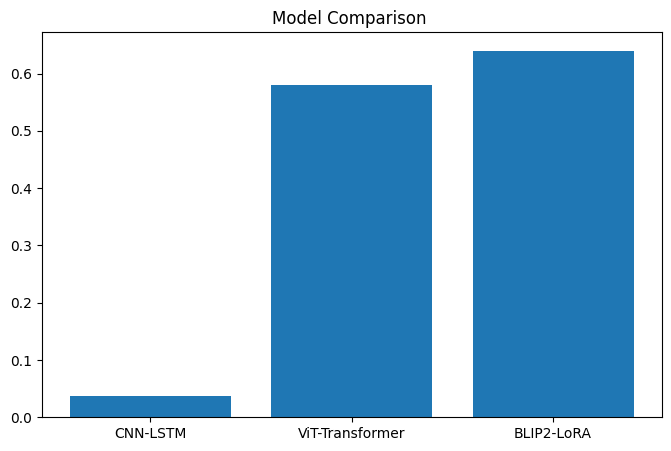

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results_table["Model"],results_table["BLEU-4"])

plt.title("Model Comparison ")

plt.savefig(graphs_dir+"/model_comparison.png")

plt.show()

In [ ]:
import os

results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

In [ ]:
results_table.to_excel(results_dir + "/captioning_results_table.xlsx", index=False)